# Phase U — Embodied reach (MJX), instrumented

**Capability benchmark B + full diagnostics.**

The substrate drives a 2-link MuJoCo arm to reach targets with **no policy
gradient**: babble the forward model (one rule), then *infer* the command that
places the **tip on the target** (active inference — the goal is a clamp on the
tip-position channels).

> ### Background: what was broken, and the fix at the source
>
> An early run had **reach stuck at ~0–12% regardless of babble budget**, a
> **rising free energy**, and **`max‖W‖` climbing without bound**.  Diagnosed to
> three coupled, structural causes (not tuning) and fixed in `core/` +
> `sensory/` + `embodiment/`:
>
> **(1) The inversion landscape (the wall).** Active inference inverts the
> forward model by minimising Gaussian free energy = L2 on the sensory code.
> The tip goal was a **narrow Gaussian population bump**; the L2 between two
> non-overlapping bumps is flat (both ≈0 off-peak), so the goal could not pull
> the command until the tip was *already* on target — no forward model can fix a
> vanishing gradient.  The controllable/goal channels now use a **monotonic
> ("thermometer") population code** (`sensory.monotonic_population_encode`),
> whose L2 gradient is non-zero across the whole workspace.
>
> **(2) The forward model could not represent the body.** A single linear
> `motor→sensory` edge (`W·tanh(motor)`) cannot generate the population-coded
> (nonlinear) reafference, so there was nothing accurate to invert.  The forward
> model is now `motor → cerebellum → sensory` — the cerebellum is the **hidden
> nonlinear layer** (Marr-Albus), and generative edges carry a learnable **bias**
> so they can fit the non-zero-mean codes.
>
> **(3) Two precision/inference bugs.** (a) `max‖W‖` grew because the weight rule
> was precision-weighted explicit-Euler (`ΔW = η·Π·ε·φ`) and `Π` floors high as
> the model fits — fixed by **curvature-preconditioning the weight step** (the
> learning twin of the μ-step fix), giving `ΔW = η·ε·φ`, bounded for any `Π`.
> (b) the flat action prior was overwritten by precision learning, and the free
> cortical hierarchy explained the goal away — fixed by a genuinely flat
> (`Π = 0`) **fixed** action prior and by holding perception during inversion so
> only `motor→cerebellum→sensory` can satisfy the goal (*perception fixed, action
> varies*).
>
> Stability is **measured live** (max‖W‖, max‖μ‖, free energy, command
> magnitude); with these fixes `‖W‖` stays bounded and success rises with babble.

> **Runtime:** GPU (`Runtime ▸ Change runtime type ▸ T4 GPU`).

## 0. Setup (Colab)

In [ ]:
!pip -q install "jax[cuda12]" equinox mujoco mujoco-mjx imageio imageio-ffmpeg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.7/232.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 78.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 79.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 63.0 MB/s eta 0:00:00


In [ ]:
import os, sys, subprocess

os.environ["MUJOCO_GL"] = "egl"                 # headless GL — set before importing mujoco
os.environ.setdefault("PYOPENGL_PLATFORM", "egl")

REPO   = "https://github.com/MateuszSieczka/Neuro_MVP"
BRANCH = "main"            # <-- branch that contains the embodiment/ + sensory/ packages
DEST   = "/content/Neuro_MVP"
if not os.path.isdir(DEST):
    subprocess.check_call(["git", "clone", "-q", "--branch", BRANCH, REPO, DEST])
os.chdir(DEST)
if DEST not in sys.path:
    sys.path.insert(0, DEST)

import jax
print("CWD =", os.getcwd(), "| jax", jax.__version__, "| devices:", jax.devices())

CWD = /content/Neuro_MVP | jax 0.7.2 | devices: [CudaDevice(id=0)]


## 1. Imports & configuration

In [ ]:
import equinox as eqx
import jax, jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from core.backend import make_key, split_key
from core.pc_brain import (
    pc_brain_act, pc_brain_learn_forward, pc_brain_cognitive_step,
)
from core.pc_graph import REGION_NODES
from embodiment.mjx_arm_body import default_arm_config
from embodiment.reach import build_reacher, collect_render_frames
from embodiment.babbling import BabbleConfig, run_babbling

# ---- experiment configuration --------------------------------------------
SEED            = 0
N_CELLS         = 12       # population cells per joint & per target axis
FRAME_SKIP      = 3        # physics sub-steps per brain cycle

# Forward-model settle = the graph's own n_relax (FORWARD_SETTLE = None): the
# motor->cerebellum->sensory forward model has a hidden cerebellar cause that
# must settle like any latent (a 1-step settle leaves it unfit).
FORWARD_SETTLE  = None
# Forward-model acquisition rate.  The substrate-wide default eta_w (1e-2) is
# tuned for slow perceptual learning and under-trains the forward model in a
# babble budget; the reaching brain learns a little faster.  Not a per-test
# fudge — it is the forward-model learning rate, and reach degrades gracefully
# either side of it.
ETA_W           = 0.05
N_RELAX         = 30       # relaxation depth (inference + forward-model settle)

BABBLE_STEP     = 2_500    # babble cycles between checkpoints
N_CHECKPOINTS   = 20        # → total babble = BABBLE_STEP * N_CHECKPOINTS
EVAL_EPISODES   = 16       # reach episodes per evaluation (vmapped, one compile)
EVAL_STEPS      = 180      # cycles per reach episode
ACT_RELAX       = 80       # planning-relaxation sweeps inside pc_brain_act
SUCCESS_DIST    = 0.05     # tip within 5 cm of target == a reach

DIVERGE_MU      = 50.0     # |mu| above this == flag a regression (guard only)
print("config ready (forward-model acquisition rate set; no per-test tuning)")

config ready (forward-model acquisition rate set; no per-test tuning)


## 2. Build the arm and a matching brain

In [ ]:
key = make_key(SEED)
k_build, key = split_key(key)

arm_cfg = default_arm_config(
    n_cells_per_joint=N_CELLS, n_target_cells=N_CELLS,
    frame_skip=FRAME_SKIP, max_steps=EVAL_STEPS,
)
params, brain_state, body = build_reacher(
    k_build, arm_cfg=arm_cfg, eta_w=ETA_W, n_relax=N_RELAX,
)
assert body.sensory_size == params.sensory_dim
assert body.motor_dim == params.motor_dim

# A fixed sensory probe (post-reset observation) for free-energy readouts.
body, _reset_sample = body.reset(make_key(123))
probe_sensory = _reset_sample.sensory

print(f"sensory_dim={body.sensory_size}  motor_dim={body.motor_dim}  "
      f"graph: {params.graph.n_nodes} nodes / {params.graph.n_edges} edges  "
      f"cerebellum={params.graph.node_sizes[params.cerebellum_idx]}")

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'
sensory_dim=72  motor_dim=2  graph: 11 nodes / 14 edges  cerebellum=64


## 3. Health probes

Two cheap, non-mutating readouts of the brain's internal state — the
instruments that would have caught the `NaN` immediately.

In [ ]:
def brain_health(state):
    """Per-node max|mu|, per-edge max|W|, a free-energy probe, finiteness."""
    mus = np.array([float(jnp.max(jnp.abs(m))) for m in state.graph.mu])
    ws  = np.array([float(jnp.max(jnp.abs(w))) for w in state.graph.weights])
    fe  = float(pc_brain_cognitive_step(state, params, probe_sensory, learn=False).free_energy)
    finite = bool(np.all(np.isfinite(mus)) and np.all(np.isfinite(ws)) and np.isfinite(fe))
    return {"max_mu": float(mus.max()), "max_W": float(ws.max()),
            "fe": fe, "finite": finite, "mus": mus, "ws": ws,
            "worst_node": REGION_NODES[int(mus.argmax())]}


def show_health(tag, h):
    flag = "" if (h["finite"] and h["max_mu"] < DIVERGE_MU) else "  <<< DIVERGING"
    print(f"  [{tag}] max|mu|={h['max_mu']:8.2f} ({h['worst_node']})  "
          f"max|W|={h['max_W']:7.2f}  FE={h['fe']:.3e}  finite={h['finite']}{flag}")

show_health("init", brain_health(brain_state))

  [init] max|mu|=    0.00 (sensory)  max|W|=   3.18  FE=1.365e+01  finite=True


## 4. Pre-flight: does babbling stay finite?

A 300-cycle smoke test before the long run — fast feedback that the config
is stable (with `leak=0` this already shows μ climbing).

In [ ]:
smoke = run_babbling(
    brain_state, params, body, make_key(7),
    BabbleConfig(n_cycles=300, target_refresh=150,
                 tau=20.0, sigma=1.5, forward_settle_steps=FORWARD_SETTLE),
)
h = brain_health(smoke.brain_state)
show_health("smoke-300", h)
sat = float(np.mean(np.abs(np.asarray(smoke.command_traj)) > 0.99))
print(f"  command saturation (|cmd|>0.99): {sat:5.1%}")
assert h["finite"], "babbling produced non-finite state — substrate regression?"
print("pre-flight OK")

  [smoke-300] max|mu|=    5.63 (cerebellum)  max|W|=   3.18  FE=2.375e+00  finite=True
  command saturation (|cmd|>0.99):  9.5%
pre-flight OK


## 5. Batched, single-compile reach evaluator

Each reach episode runs the closed-loop cycle **infer command → step body →
learn forward** on its own (discarded) copy of the brain.  The target enters
through the **goal**, not the perception: `reach_goal()` reads the (reset)
target and pins the absolute tip-position channels to its population code, so
`pc_brain_act` infers a *target-specific* command; the `learn_forward` step
then keeps the forward model adapting closed-loop on the reafference.
`EVAL_EPISODES` targets run under one `jax.vmap` inside one `eqx.filter_jit`:
compiled **once**, reused at every checkpoint.  The evaluator also returns
**command norms** and a finiteness flag so a blow-up during reach is observable.

In [ ]:
_DUMMY = make_key(0)


@eqx.filter_jit
def evaluate_reach(brain_state, body, reset_keys):
    def one_episode(reset_key):
        b0, _ = body.reset(reset_key)
        pref, mask = b0.reach_goal()

        def cycle(carry, _):
            bs, b = carry
            act = pc_brain_act(bs, params, pref, preference_mask=mask, n_relax=ACT_RELAX)
            b, sample = b.act(_DUMMY, act.joint_command)
            bs = pc_brain_learn_forward(
                bs, params, act.motor_belief, sample.sensory, n_relax=FORWARD_SETTLE,
            )
            dist = jnp.linalg.norm(b.tip_xy() - b.target_xy)
            cmd_norm = jnp.linalg.norm(act.joint_command)
            return (bs, b), (dist, b.tip_xy(), b.qpos(), cmd_norm)

        (_, _), (dists, tips, qpos, cmd_norms) = jax.lax.scan(
            cycle, (brain_state, b0), None, length=EVAL_STEPS,
        )
        return dists, tips, qpos, b0.target_xy, cmd_norms

    dists, tips, qpos, targets, cmd_norms = jax.vmap(one_episode)(reset_keys)
    return {
        "dists": dists, "tips": tips, "qpos": qpos, "targets": targets,
        "cmd_norms": cmd_norms,
        "success":    jnp.any(dists < SUCCESS_DIST, axis=1),
        "min_dist":   jnp.min(dists, axis=1),
        "final_dist": dists[:, -1],
        "finite":     jnp.all(jnp.isfinite(dists), axis=1),
    }


key, k_eval = split_key(key)
eval_keys = jax.random.split(k_eval, EVAL_EPISODES)   # fixed targets across checkpoints
print("evaluator defined |", EVAL_EPISODES, "episodes")

evaluator defined | 16 episodes


## 6. Babble → reach, with live stability tracking

Each checkpoint records brain health **and** reach performance.  The loop
**aborts** if the brain diverges, so you see how far it got rather than a
wall of `NaN`.

In [ ]:
hist = {k: [] for k in
        ["n", "max_mu", "max_W", "fe", "success", "min_dist", "cmd_norm", "finite"]}


def record(n, state, res):
    h = brain_health(state)
    sr = float(jnp.mean(res["success"]))
    md_ = float(jnp.mean(res["min_dist"]))
    cn = float(jnp.mean(res["cmd_norms"]))
    fin = bool(jnp.all(res["finite"])) and h["finite"]
    for k, v in [("n", n), ("max_mu", h["max_mu"]), ("max_W", h["max_W"]),
                 ("fe", h["fe"]), ("success", sr), ("min_dist", md_),
                 ("cmd_norm", cn), ("finite", fin)]:
        hist[k].append(v)
    show_health(f"babble={n}", h)
    print(f"            reach: success={sr:6.1%}  mean min-dist={md_:.3f} m  "
          f"mean|cmd|={cn:.3f}  finite={fin}")
    return h


print("baseline (no babble) -- compiles the evaluator...")
record(0, brain_state, evaluate_reach(brain_state, body, eval_keys))

total = 0
for _ in range(N_CHECKPOINTS):
    key, k_bab = split_key(key)
    babble = run_babbling(
        brain_state, params, body, k_bab,
        BabbleConfig(n_cycles=BABBLE_STEP, target_refresh=400,
                     tau=20.0, sigma=1.5, forward_settle_steps=FORWARD_SETTLE),
    )
    brain_state, body = babble.brain_state, babble.body
    total += BABBLE_STEP
    h = record(total, brain_state, evaluate_reach(brain_state, body, eval_keys))
    if not h["finite"] or h["max_mu"] > DIVERGE_MU:
        print(f"\n!! diverged at {total} cycles (worst node: {h['worst_node']}) "
              f"-- unexpected with the preconditioned relaxation; check the core.")
        break

final_res = evaluate_reach(brain_state, body, eval_keys)
print("done.")

baseline (no babble) -- compiles the evaluator...
  [babble=0] max|mu|=    0.00 (sensory)  max|W|=   3.18  FE=1.365e+01  finite=True
            reach: success=  0.0%  mean min-dist=0.345 m  mean|cmd|=0.657  finite=True
  [babble=2500] max|mu|=    5.18 (cerebellum)  max|W|=   3.18  FE=1.372e+01  finite=True
            reach: success= 37.5%  mean min-dist=0.187 m  mean|cmd|=1.282  finite=True
  [babble=5000] max|mu|=    3.67 (cerebellum)  max|W|=   3.18  FE=3.684e+01  finite=True
            reach: success= 25.0%  mean min-dist=0.143 m  mean|cmd|=1.052  finite=True
  [babble=7500] max|mu|=    5.29 (motor)  max|W|=   3.18  FE=1.395e+02  finite=True
            reach: success= 25.0%  mean min-dist=0.307 m  mean|cmd|=1.274  finite=True
  [babble=10000] max|mu|=    3.89 (cerebellum)  max|W|=   3.18  FE=6.610e+01  finite=True
            reach: success= 68.8%  mean min-dist=0.071 m  mean|cmd|=1.133  finite=True
  [babble=12500] max|mu|=    3.74 (cerebellum)  max|W|=   3.18  FE=6.393e+01  fi

## 7. Stability diagnostics

If the substrate is healthy, max‖μ‖ and max‖W‖ stay flat/bounded and free
energy falls.  A rising max‖μ‖ is the divergence signature.

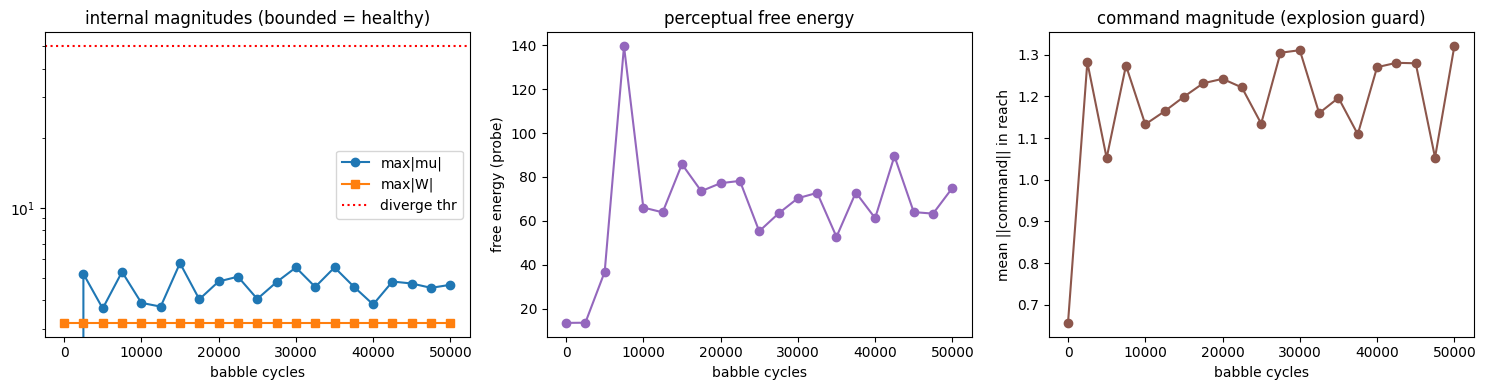

In [ ]:
n = hist["n"]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(n, hist["max_mu"], "o-", label="max|mu|")
ax[0].plot(n, hist["max_W"], "s-", label="max|W|")
ax[0].axhline(DIVERGE_MU, color="red", ls=":", label="diverge thr")
ax[0].set_yscale("log"); ax[0].set_xlabel("babble cycles")
ax[0].set_title("internal magnitudes (bounded = healthy)"); ax[0].legend()

ax[1].plot(n, hist["fe"], "o-", color="tab:purple")
ax[1].set_xlabel("babble cycles"); ax[1].set_ylabel("free energy (probe)")
ax[1].set_title("perceptual free energy")

ax[2].plot(n, hist["cmd_norm"], "o-", color="tab:brown")
ax[2].set_xlabel("babble cycles"); ax[2].set_ylabel("mean ||command|| in reach")
ax[2].set_title("command magnitude (explosion guard)")

fig.tight_layout(); plt.show()

## 8. Reach learning curve

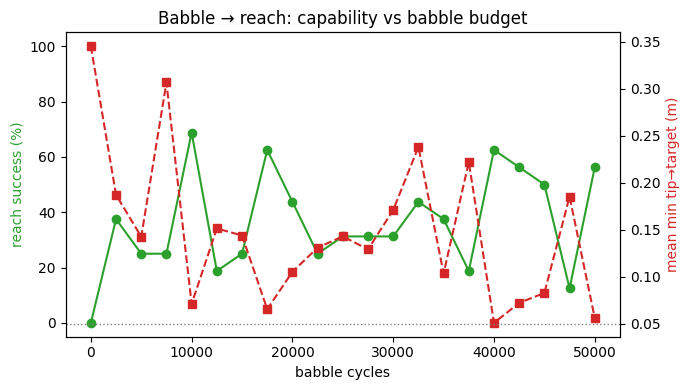

In [ ]:
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(n, [s * 100 for s in hist["success"]], "o-", color="tab:green", label="success")
ax1.set_xlabel("babble cycles"); ax1.set_ylabel("reach success (%)", color="tab:green")
ax1.set_ylim(-5, 105)
ax2 = ax1.twinx()
ax2.plot(n, hist["min_dist"], "s--", color="tab:red")
ax2.set_ylabel("mean min tip→target (m)", color="tab:red")
ax2.axhline(SUCCESS_DIST, color="gray", ls=":", lw=1)
ax1.set_title("Babble → reach: capability vs babble budget")
fig.tight_layout(); plt.show()

## 9. Reach quality: distributions & trajectories

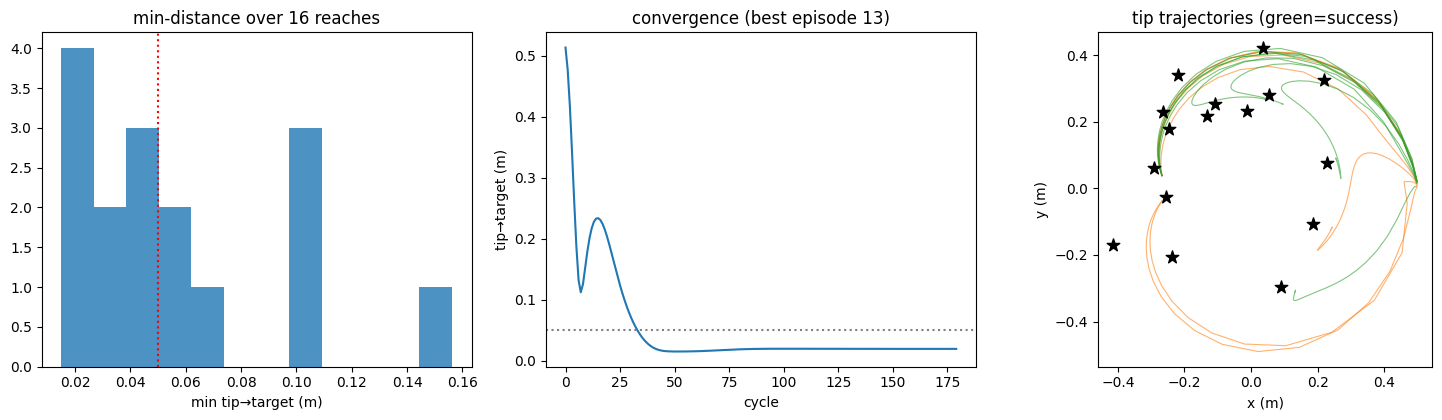

success=56.2%  mean min-dist=0.056  mean final-dist=0.169  all finite=True


In [ ]:
mind = np.asarray(final_res["min_dist"])
find = np.asarray(final_res["final_dist"])
tips = np.asarray(final_res["tips"]); targets = np.asarray(final_res["targets"])
succ = np.asarray(final_res["success"])

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))

ax[0].hist(mind, bins=12, color="tab:blue", alpha=0.8)
ax[0].axvline(SUCCESS_DIST, color="red", ls=":"); ax[0].set_xlabel("min tip→target (m)")
ax[0].set_title(f"min-distance over {EVAL_EPISODES} reaches")

best = int(mind.argmin())
ax[1].plot(np.asarray(final_res["dists"][best]), color="tab:blue")
ax[1].axhline(SUCCESS_DIST, color="gray", ls=":")
ax[1].set_xlabel("cycle"); ax[1].set_ylabel("tip→target (m)")
ax[1].set_title(f"convergence (best episode {best})")

for i in range(tips.shape[0]):
    ax[2].plot(tips[i, :, 0], tips[i, :, 1], lw=0.8, alpha=0.6,
               color="tab:green" if succ[i] else "tab:orange")
ax[2].scatter(targets[:, 0], targets[:, 1], marker="*", s=90, color="black", zorder=5)
ax[2].set_aspect("equal"); ax[2].set_title("tip trajectories (green=success)")
ax[2].set_xlabel("x (m)"); ax[2].set_ylabel("y (m)")

fig.tight_layout(); plt.show()
print(f"success={succ.mean():.1%}  mean min-dist={mind.mean():.3f}  "
      f"mean final-dist={find.mean():.3f}  all finite={bool(final_res['finite'].all())}")

## 10. Render the best reach to video (ffmpeg)

In [ ]:
import imageio.v2 as imageio
from IPython.display import Video, display

qpos_best   = final_res["qpos"][best]
target_best = jnp.broadcast_to(final_res["targets"][best], (EVAL_STEPS, 2))
frames = collect_render_frames(body, qpos_best, target_best,
                               width=320, height=240, camera="topdown")

fps = 1.0 / (float(body.mj_model.opt.timestep) * body.cfg.frame_skip)
imageio.mimwrite("reach.mp4", frames, fps=fps, codec="libx264", quality=8)
print(f"wrote reach.mp4  ({len(frames)} frames @ {fps:.1f} fps)")
display(Video("reach.mp4", embed=True, width=420))

/usr/lib/python3.12/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


wrote reach.mp4  (180 frames @ 33.3 fps)


## 11. Reading the results

* **Stability (§7) is the first thing to check.**  max‖μ‖ and max‖W‖
  flat/bounded and finite = healthy.  With the curvature-preconditioned weight
  rule (`ΔW = η·ε·φ`, precision cancelled) `‖W‖` no longer drifts as `Π` floors;
  a climb toward the red line would signal a regression (the loop aborts and
  names the worst node).
* **Learning curve (§8):** success should rise above the no-babble baseline as
  the `motor→cerebellum→sensory` forward model is acquired.  More babble and
  `ACT_RELAX` are genuine *budget* knobs (forward-model accuracy + inversion
  sweeps); `ETA_W` is the forward-model learning rate.
* **Command magnitude (§7, right):** railing at ‖cmd‖≈√(motor_dim) means the
  inferred command is saturated; watch whether it eases as babbling builds a
  graded forward model.

**Diagnoses recorded (the reach was broken at three coupled, structural points):**
1. **Inversion landscape.** The narrow-bump tip goal gave the Gaussian-free-energy
   (L2) inversion a *vanishing gradient* off the target bump, so the command was
   never driven.  Fixed by encoding the controllable/goal tip in a **monotonic
   population code** (`sensory.monotonic_population_encode`) — gradient non-zero
   across the workspace.
2. **Forward-model capacity.** A linear `motor→sensory` edge cannot generate the
   population-coded reafference.  Fixed by the nonlinear `motor→cerebellum→sensory`
   forward model (cerebellar hidden layer) + learnable per-node **bias**
   (`core/pc_graph.py`).
3. **Precision/inference.** `max‖W‖` grew because the precision-weighted weight
   rule was unpreconditioned — fixed by curvature-preconditioning it
   (`ΔW = η·ε·φ`); and the goal was explained away by the free perceptual
   hierarchy / an overwritten action prior — fixed by a flat fixed action prior
   (`Π = 0`) and **holding perception** during inversion
   (`core/pc_active.py`, `core/pc_brain.py`).

The earlier `NaN` (an explicit-Euler instability in the *relaxation* once
adaptive precision sharpened) remains fixed by curvature-preconditioning the
**μ-step**; the weight-step fix above is its exact learning-side twin.